In [1]:
import yfinance as yf
import pandas as pd

In [14]:
import os
print(os.getcwd())

C:\Users\ARYAN DASH\stock_price_direc\notebooks


In [15]:
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent   
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"

In [2]:
ticker = "HDFCBANK.NS"
start_date = "2015-01-01"
end_date = "2025-01-01"  

In [3]:
df = yf.download(ticker, start=start_date, end=end_date, interval="1d")

[*********************100%***********************]  1 of 1 completed


In [4]:
print(df.columns)

MultiIndex([( 'Close', 'HDFCBANK.NS'),
            (  'High', 'HDFCBANK.NS'),
            (   'Low', 'HDFCBANK.NS'),
            (  'Open', 'HDFCBANK.NS'),
            ('Volume', 'HDFCBANK.NS')],
           names=['Price', 'Ticker'])


In [5]:
print(df.shape)

(2467, 5)


In [6]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2015-01-01,213.700867,214.228365,212.129619,213.465182,3544940
2015-01-02,216.675003,217.572859,213.330499,213.330499,5900384
2015-01-05,214.845627,217.853435,214.385465,217.729982,4796000
2015-01-06,211.501114,214.710945,210.446131,214.138565,8219680
2015-01-07,212.118362,213.543703,210.154304,210.928707,5746112


In [7]:
df.tail()

Price,Close,High,Low,Open,Volume
Ticker,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS,HDFCBANK.NS
Date,,,,,
2024-12-24,872.626831,877.771052,868.477509,874.543821,14485834
2024-12-26,869.059875,879.372606,864.206826,872.845278,10481678
2024-12-27,872.699646,876.436470,868.259094,871.025368,7259330
2024-12-30,862.823730,880.828533,859.475114,869.763556,22222218
2024-12-31,860.372925,864.716440,856.854464,859.135433,14117236


In [8]:
  if isinstance(df.columns, pd.MultiIndex):
      df.columns = df.columns.get_level_values(0)

In [10]:
print(df.columns)

Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='str', name='Price')


In [11]:
df.isnull().sum()

Price
Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [16]:
df.to_csv(DATA_RAW / f"{ticker}_raw_{start_date}_{end_date}.csv")

In [17]:
import matplotlib.pyplot as plt

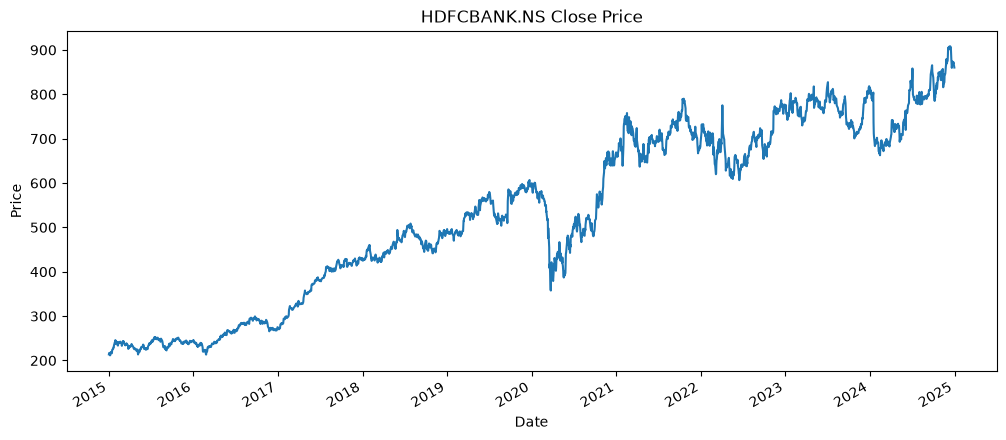

In [18]:
df['Close'].plot(figsize=(12, 5), title=f"{ticker} Close Price")
plt.ylabel("Price")
plt.show()

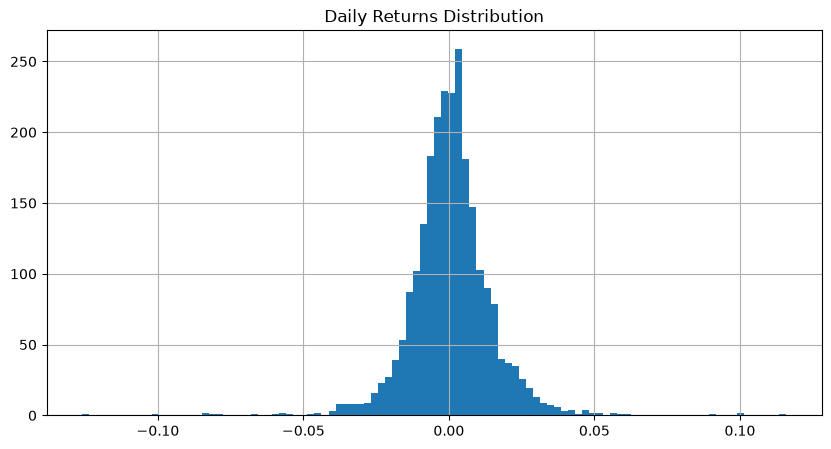

count    2466.000000
mean        0.000667
std         0.014302
min        -0.126069
25%        -0.006396
50%         0.000622
75%         0.007313
max         0.115996
Name: daily_return, dtype: float64

In [19]:
df['daily_return'] = df['Close'].pct_change()
df['daily_return'].hist(bins=100, figsize=(10, 5))
plt.title("Daily Returns Distribution")
plt.show()

df['daily_return'].describe()

In [20]:
df['target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

In [21]:
df = df.iloc[:-1]

In [22]:
df['target'].value_counts(normalize=True) * 100

target
1    52.189781
0    47.810219
Name: proportion, dtype: float64

In [23]:
df.to_csv(DATA_PROCESSED / f"{ticker}_labeled_{start_date}_{end_date}.csv")